# Life Expectancy vs. GDP Per Capita
## Does money buy a longer life — and has that relationship changed over time?

**Tools:** Python, Pandas, Matplotlib, Seaborn  
**Data source:** Our World in Data / World Bank

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

In [2]:
df = pd.read_csv('data/life-expectancy-vs-gdp-per-capita.csv')
print(df.head())

        Entity Code  Year  Life expectancy at birth  GDP per capita  \
0  Afghanistan  AFG  1950                   28.1563          1156.0   
1  Afghanistan  AFG  1951                   28.5836          1170.0   
2  Afghanistan  AFG  1952                   29.0138          1189.0   
3  Afghanistan  AFG  1953                   29.4521          1240.0   
4  Afghanistan  AFG  1954                   29.6975          1245.0   

   Population World region according to OWID GDP per capita (Annotations)  
0   7776180.0                           Asia                          NaN  
1   7879343.0                           Asia                          NaN  
2   7987784.0                           Asia                          NaN  
3   8096703.0                           Asia                          NaN  
4   8207954.0                           Asia                          NaN  


In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29912 entries, 0 to 29911
Data columns (total 8 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Entity                          29912 non-null  object 
 1   Code                            27684 non-null  object 
 2   Year                            29912 non-null  int64  
 3   Life expectancy at birth        21565 non-null  float64
 4   GDP per capita                  21586 non-null  float64
 5   Population                      28292 non-null  float64
 6   World region according to OWID  27674 non-null  object 
 7   GDP per capita (Annotations)    28 non-null     object 
dtypes: float64(3), int64(1), object(4)
memory usage: 1.8+ MB
None


## Data Cleaning
Before analysis we'll rename columns for readability, drop unhelpful columns, and handle missing values.

In [4]:
df = df.rename(columns = {
    'Entity': 'country', 
    'Code': 'code',
    'Year': 'year',
    'Life expectancy at birth': 'life_expectancy', 
    'GDP per capita': 'gdp_per_capita',
    'Population': 'population',
    'World region according to OWID': 'region'
})

print(df.head())

       country code  year  life_expectancy  gdp_per_capita  population region  \
0  Afghanistan  AFG  1950          28.1563          1156.0   7776180.0   Asia   
1  Afghanistan  AFG  1951          28.5836          1170.0   7879343.0   Asia   
2  Afghanistan  AFG  1952          29.0138          1189.0   7987784.0   Asia   
3  Afghanistan  AFG  1953          29.4521          1240.0   8096703.0   Asia   
4  Afghanistan  AFG  1954          29.6975          1245.0   8207954.0   Asia   

  GDP per capita (Annotations)  
0                          NaN  
1                          NaN  
2                          NaN  
3                          NaN  
4                          NaN  


In [5]:
df = df.drop(columns='GDP per capita (Annotations)')
print(df.head())

       country code  year  life_expectancy  gdp_per_capita  population region
0  Afghanistan  AFG  1950          28.1563          1156.0   7776180.0   Asia
1  Afghanistan  AFG  1951          28.5836          1170.0   7879343.0   Asia
2  Afghanistan  AFG  1952          29.0138          1189.0   7987784.0   Asia
3  Afghanistan  AFG  1953          29.4521          1240.0   8096703.0   Asia
4  Afghanistan  AFG  1954          29.6975          1245.0   8207954.0   Asia


In [6]:
df = df.dropna(subset=['life_expectancy', 'gdp_per_capita'])
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 13239 entries, 0 to 29910
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   country          13239 non-null  object 
 1   code             13239 non-null  object 
 2   year             13239 non-null  int64  
 3   life_expectancy  13239 non-null  float64
 4   gdp_per_capita   13239 non-null  float64
 5   population       13239 non-null  float64
 6   region           13220 non-null  object 
dtypes: float64(3), int64(1), object(3)
memory usage: 827.4+ KB
None


## Data Cleaning Summary
- Renamed columns for readability
- Dropped the GDP per capita (Annotations) column (28 non-null values out of 29,912)
- Dropped rows missing life_expectancy or gdp_per_capita values
- Clean dataset: 13,239 rows ready for analysis
```

## Exploratory Analysis
I'll examine the relationship between GDP per capita and life expectancy globally, by region, and across time.

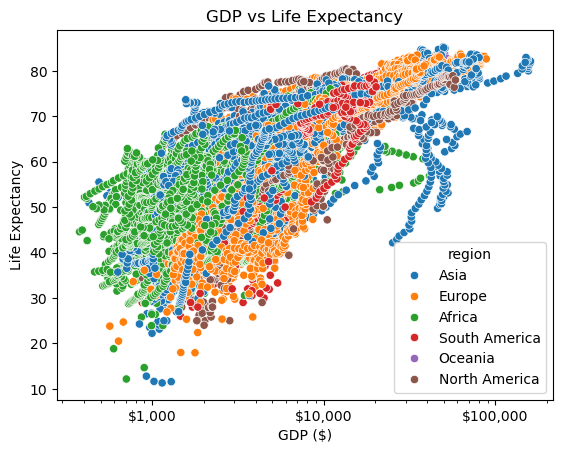

In [7]:
sns.scatterplot(data=df, x='gdp_per_capita', y='life_expectancy', hue= 'region')
plt.title('GDP vs Life Expectancy')
plt.xlabel('GDP ($)')
plt.ylabel('Life Expectancy')

def format_gdp(x, p):
    return f'${int(x):,}'

plt.xscale('log')
plt.gca().xaxis.set_major_formatter(FuncFormatter(format_gdp))
plt.show()


## Regional Analysis
Now that I've established a global relationship between GDP and life expectancy, 
I want to understand how life expectancy varies across world regions. 
Are some regions consistently living longer regardless of wealth?

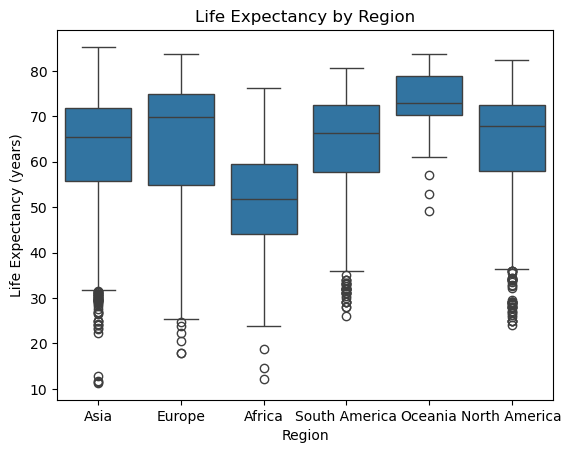

In [9]:
sns.boxplot(data=df, x='region', y='life_expectancy')
plt.title('Life Expectancy by Region')
plt.xlabel('Region')
plt.ylabel('Life Expectancy (years)')
plt.show()

### Finding 2: Regional Distribution
Life expectancy is fairly consistent across most regions, with Africa performing significantly below the global trend and Oceania performing above it. Asia shows the greatest internal variance, reflecting the enormous economic and social diversity across the continent.

## Time Analysis
Now that I better understand regional life expectancy, I would like to examine 
how life expectancy has changed over time across regions since 1950.

In [10]:
regional_trends = df.groupby(['region', 'year'])['life_expectancy'].mean().reset_index()
print(regional_trends.head())

   region  year  life_expectancy
0  Africa  1921        28.000000
1  Africa  1927        23.912500
2  Africa  1937        26.387000
3  Africa  1945        28.811000
4  Africa  1950        38.931414


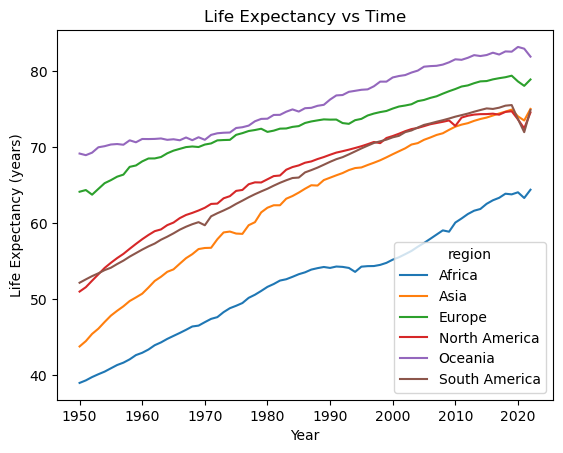

In [12]:
regional_trends_filtered = regional_trends[regional_trends['year'] >= 1950]

sns.lineplot(data=regional_trends_filtered, x='year', y='life_expectancy', hue='region')
plt.title('Life Expectancy vs Time')
plt.xlabel('Year')
plt.ylabel('Life Expectancy (years)')
plt.show()

### Finding 3: A Rising Tide
Life expectancy has increased steadily across all regions since 1950. Asia shows 
the steepest improvement, currently matching the Americas in life expectancy. Africa, while still the lowest globally, 
has gained approximately 25 years of life expectancy over the period, demonstrating an increased modernization of the region in terms of healthcare. The slight dip visible around 2020 across all regions reflects the 
measurable global impact of COVID-19 on life expectancy.




## GDP Analysis
The continued increase of life expectancy over the last 70 years is clear from the previous chart. The final analysis will be GDP per capita against time to understand how GDP has changed in the same time frame that our data on life expectancy reflects.

In [16]:
gdp_trends = df.groupby(['region', 'year'])['gdp_per_capita'].mean().reset_index()
print(gdp_trends.head())

   region  year  gdp_per_capita
0  Africa  1921     1434.224600
1  Africa  1927     1072.896900
2  Africa  1937     1018.684270
3  Africa  1945      986.810030
4  Africa  1950     1431.259448


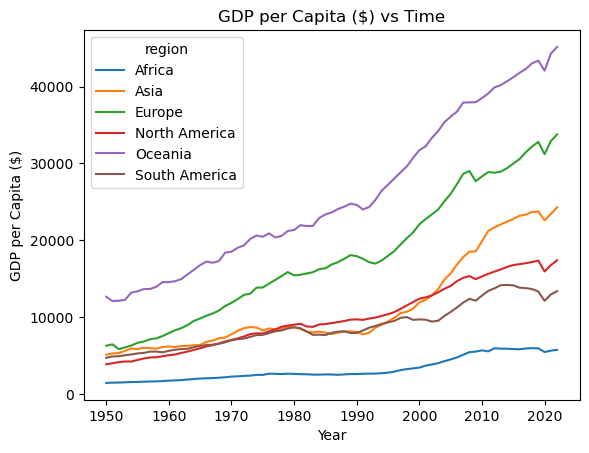

In [17]:
gdp_trends_filtered = gdp_trends[gdp_trends['year'] >= 1950]

sns.lineplot(data=gdp_trends_filtered, x='year', y='gdp_per_capita', hue='region')
plt.title('GDP per Capita ($) vs Time')
plt.xlabel('Year')
plt.ylabel('GDP per Capita ($)')
plt.show()

### Finding 4: Correlation Without Causation
The regional order of GDP per capita mirrors the regional order of life expectancy — 
Oceania and Europe lead both rankings while Africa sits at the bottom of both. 
However, the rate of GDP growth does not consistently reflect the rate of life 
expectancy improvement. Asia's life expectancy rose steeply well before its dramatic 
GDP explosion in the 1990s, suggesting that factors beyond wealth — such as public 
health infrastructure, vaccines, and access to clean water — play a significant role. 
South America and North America further reinforce this point, showing that high GDP 
does not automatically translate to proportionally higher life expectancy. Africa's recent life expectancy boom does not appear to be accounted for by GDP alone. Wealth 
matters, but it is not the whole story.

## Conclusion

This analysis set out to answer a single question: does money buy a longer life, 
and has that relationship changed over time?

The data suggests the answer is yes — but with important nuance. GDP per capita 
is strongly correlated with life expectancy globally, with the greatest gains 
occurring in the first $10,000 of wealth. Beyond that threshold, diminishing 
returns set in and additional wealth produces progressively smaller improvements 
in how long people live.

Regionally, the rankings of GDP and life expectancy are consistent — wealthier 
regions live longer. However, the rate of improvement tells a different story. 
Asia's dramatic rise in life expectancy preceded its economic boom, and Africa 
has made remarkable gains despite remaining the lowest GDP region globally. 
This suggests that factors beyond wealth — public health infrastructure, medical 
knowledge, access to clean water, etc. — are powerful drivers of life 
expectancy in their own right.

The relationship between money and longevity is real, but it is not the whole story. 
A rising tide of global health improvements has lifted life expectancy across all 
regions since 1950, regardless of wealth. Covid has introduced an interesting factor into the data. How the lasting effects of that influence life expectancy and GDP moving forward may be interesting to examine once there is enough data.